# FMCG Supply Chain & Demand Analytics

Narrative walkthrough of the pipeline in `src/`. Each section states the
question, runs the module, and interprets the result.

**Contents**
1. Setup and data preparation
2. Delivery performance (OTIF)
3. ABC-XYZ segmentation
4. Demand forecasting
5. Inventory optimisation
6. Recommendations

## 1. Setup and data preparation

The pipeline reads the real Kaggle DataCo file if it is present in `data/raw/`,
and otherwise falls back to a schema-compatible synthetic generator so the
notebook runs on a fresh clone.

Cleaning does four things: coerce dates and numerics, drop duplicate order
lines, remove rows with invalid quantity or sales, and flag cancelled and
suspected-fraud lines. Those flagged lines are **excluded from the OTIF
denominator** rather than deleted — an order that was cancelled never shipped,
so counting it as a delivery failure would blame logistics for a commercial
decision.

In [1]:
import sys, warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import pandas as pd, numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

import data_prep, otif_analysis, abc_xyz, forecasting, inventory

orders, daily, audit = data_prep.run()
print(f"source          : {audit['source']}")
print(f"rows in / out   : {audit['rows_in']:,} / {audit['rows_out']:,}")
print(f"fulfilled lines : {orders['is_fulfilled'].sum():,}")
print(f"date range      : {orders.order_date.min().date()} to {orders.order_date.max().date()}")
print(f"SKUs            : {orders.product_id.nunique()}")

source          : synthetic
rows in / out   : 237,436 / 237,436
fulfilled lines : 231,836
date range      : 2015-01-01 to 2017-12-31
SKUs            : 120


In [2]:
orders[["order_date", "product_id", "category_name", "shipping_mode",
        "order_region", "days_for_shipment_scheduled", "days_for_shipping_real",
        "shipping_slip_days", "on_time", "sales"]].head()

,order_date,product_id,category_name,shipping_mode,order_region,days_for_shipment_scheduled,days_for_shipping_real,shipping_slip_days,on_time,sales
0,2015-01-01,SKU-0022,Beverages,Standard Class,South America,4,8,4,False,4.03
1,2015-01-01,SKU-0059,Personal Care,Standard Class,Central America,4,7,3,False,20.38
2,2015-01-01,SKU-0059,Personal Care,Standard Class,Western Europe,4,3,-1,True,28.30
3,2015-01-01,SKU-0057,Personal Care,Second Class,Western Europe,2,1,-1,True,44.54
4,2015-01-01,SKU-0055,Personal Care,Standard Class,West Africa,4,6,2,False,15.58


### The daily demand grid

Order lines are collapsed to one row per SKU per day, then **reindexed to a
complete calendar with zeros filled in**.

This step is easy to skip and quietly ruins everything downstream. Days with no
orders simply don't exist in the raw aggregation, so a lag-7 feature computed on
the gappy frame means "seven *observed* days back", not "seven days back" — the
offset varies per SKU and per row. Every rolling window and seasonal comparison
silently shifts.

In [3]:
print(f"daily grid rows : {len(daily):,}")
print(f"expected        : {daily.product_id.nunique()} SKUs x "
      f"{daily.order_date.nunique()} days = "
      f"{daily.product_id.nunique() * daily.order_date.nunique():,}")
print(f"zero-demand days: {(daily.units == 0).mean():.1%}")

daily grid rows : 131,520
expected        : 120 SKUs x 1096 days = 131,520
zero-demand days: 57.9%


## 2. Delivery performance (OTIF)

OTIF counts a line as a success only if it was fulfilled **and** arrived by the
promised date:

    on_time = days_for_shipping_real <= days_for_shipment_scheduled

The headline late rate is the least interesting output. The question that leads
to action is *where the failures concentrate*, so every breakdown reports each
segment's **share of all late orders** alongside its rate. A segment with a
terrible rate on trivial volume is not where you spend effort.

In [4]:
otif = otif_analysis.run(orders)
k = otif["kpis"]

print(f"On-time rate         : {k['on_time_rate']:.1%}")
print(f"Late rate            : {k['late_rate']:.1%}")
print(f"Avg slip when late   : {k['avg_slip_days_when_late']:.2f} days")
print(f"Avg transit          : {k['avg_transit_days']:.2f} days")
print(f"Revenue on late lines: {k['revenue_on_late_orders']:,.0f}")

On-time rate         : 42.2%
Late rate            : 57.8%
Avg slip when late   : 1.79 days
Avg transit          : 3.78 days
Revenue on late lines: 2,958,185


In [5]:
otif["by_mode"][["shipping_mode", "lines", "late_rate",
                 "volume_share", "late_share"]]

,shipping_mode,lines,late_rate,volume_share,late_share
0,Standard Class,139135,0.640939,0.600144,0.665331
1,Second Class,46343,0.568608,0.199896,0.196599
2,First Class,34815,0.498521,0.150171,0.129490
3,Same Day,11543,0.099627,0.049790,0.008580


One mode dominates. Standard Class combines the highest failure rate with
the largest volume share, so it carries roughly two-thirds of every late order
in the dataset. Fixing Standard Class is the entire problem; the other three
modes together are a rounding error by comparison.

In [6]:
otif["by_region"][["order_region", "lines", "late_rate", "late_share"]]

,order_region,lines,late_rate,late_share
0,Central America,43785,0.636976,0.208082
1,Western Europe,51181,0.488599,0.186572
2,South America,30152,0.662974,0.149141
3,Southeast Asia,25387,0.692717,0.131206
4,Northern Europe,28153,0.456790,0.095946
5,US Center,23075,0.515276,0.088709
6,Southern Europe,18359,0.548723,0.075160
7,West Africa,11744,0.743954,0.065185


### Is this a product problem or a logistics problem?

Chi-square tests whether the late/on-time outcome is independent of each
dimension. With n over 200,000 nearly any difference reaches significance, so
**Cramer's V** is reported alongside — it gives effect size on a 0-to-1 scale,
answering *how much* rather than merely *whether*.

In [7]:
tests = pd.DataFrame(k["tests"])
tests["significant_at_1pct"] = tests["p_value"] < 0.01
tests

,dimension,chi2,p_value,dof,cramers_v,significant_at_1pct
0,shipping_mode,14008.808140,0.000000,3,0.245816,True
1,order_region,8022.916028,0.000000,7,0.186027,True
2,category_name,5.860962,0.319984,5,0.005028,False


**The negative result is the useful one.** Product category is not
significant — late delivery is essentially independent of what is in the box.
Shipping mode has the strongest association, region is second.

That redirects the whole recommendation. You do not fix this by changing the
product mix or packaging. You fix it in the logistics network, specifically in
the Standard Class lane.

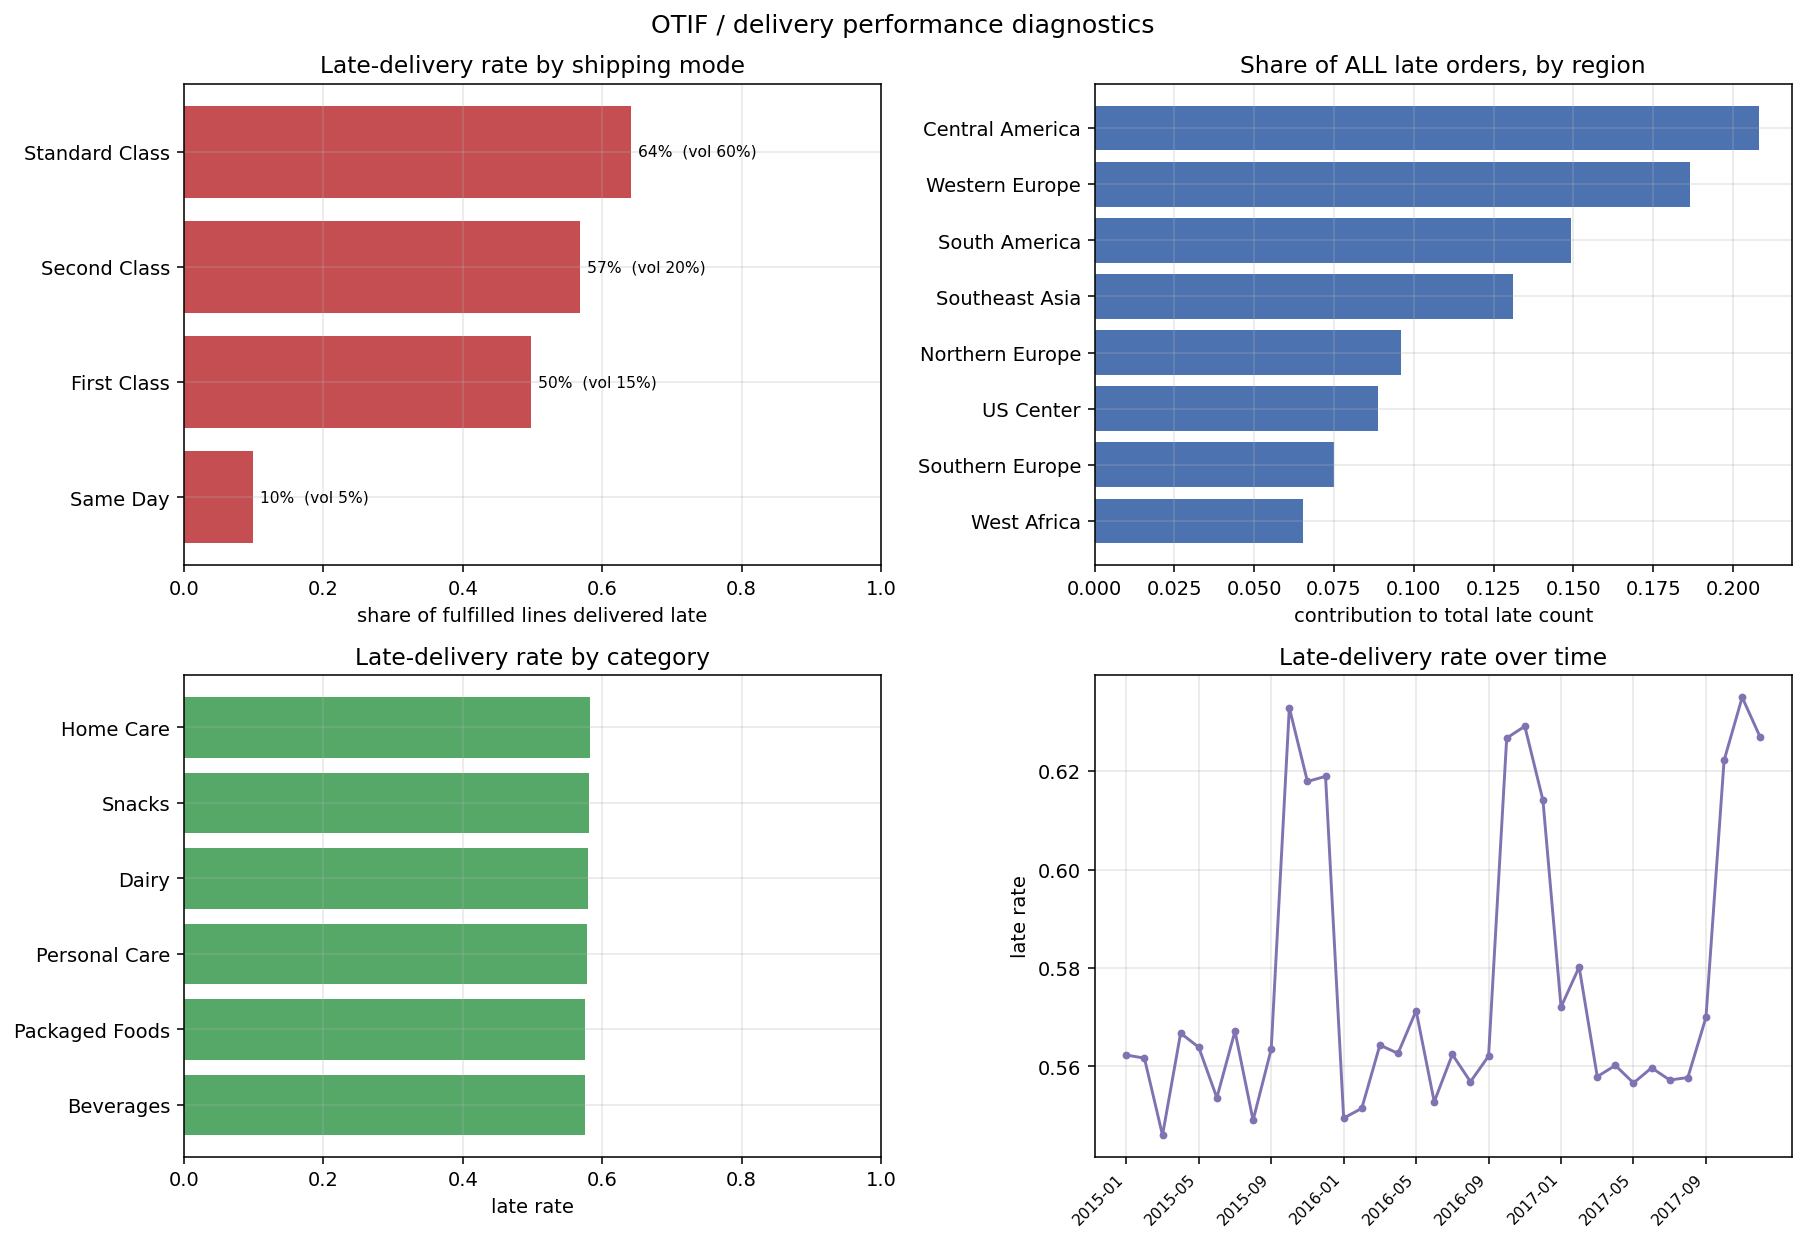

In [8]:
from IPython.display import Image, display
display(Image("../outputs/figures/01_otif_diagnostics.png"))

## 3. ABC-XYZ segmentation

**ABC — value.** Sort SKUs by revenue descending, take the running cumulative
share of total revenue, cut at 80% and 95%. The cut is on the *cumulative*
share, not each SKU's own share; this is the detail people get wrong.

**XYZ — predictability.** Coefficient of variation, CV = sigma/mu, on **weekly**
demand. X below 0.5, Y below 1.0, Z at or above 1.0. CV is unitless, so a cheap
high-volume SKU and an expensive slow mover are directly comparable.

Weekly rather than daily buckets is a deliberate choice. Daily FMCG demand is
full of structural zeros, so a daily CV mostly measures how often a SKU is
ordered rather than how unstable its demand truly is. Planners replenish weekly,
so weekly buckets measure risk at the horizon that matters.

In [9]:
seg = abc_xyz.run(daily)
h = seg["headline"]

print(f"SKUs               : {h['n_skus']}")
print(f"A-class SKUs       : {h['n_A']} ({h['A_sku_share']:.0%} of catalogue) "
      f"-> {h['A_revenue_share']:.0%} of revenue")
print(f"Erratic (Z) SKUs   : {h['n_Z']}")
print(f"AX (automatable)   : {h['n_AX']}")

SKUs               : 120
A-class SKUs       : 25 (21% of catalogue) -> 79% of revenue
Erratic (Z) SKUs   : 39
AX (automatable)   : 16


In [10]:
seg["summary"][["segment", "n_skus", "revenue_share", "avg_cv", "policy"]]

,segment,n_skus,revenue_share,avg_cv,policy
0,AX,16,0.393372,0.311514,Automate replenishment; low safety stock; tigh...
1,AY,8,0.390145,0.706773,Weekly review; seasonal buffer; forecast with ...
2,BX,18,0.083103,0.408970,Periodic auto-replenishment; standard buffer
3,BY,14,0.065930,0.638044,Monthly review; moderate buffer
4,CY,20,0.026977,0.683929,Low priority; simple reorder point
5,CZ,36,0.015242,2.398135,Make-to-order or delist; do not hold stock
6,CX,5,0.008750,0.451710,Bulk order infrequently; minimise handling cost
7,AZ,1,0.008595,1.004400,Manual planner review; high buffer or make-to-...
8,BZ,2,0.007886,1.378195,Reduce commitment; consider vendor-managed inv...


A textbook Pareto: about a fifth of the catalogue produces roughly four
fifths of revenue.

The commercially important cells are **AX** and **AZ**. AX is high value and
predictable, so it is where replenishment automation pays for itself. AZ is high
value and erratic — the smallest cell but the highest inventory risk per rupee,
because you cannot forecast it well yet cannot afford to stock out of it.

The C/Z tail is the opposite case: 36 SKUs contributing almost nothing. Holding
a 98% service buffer on those ties up capital protecting revenue that barely
exists, which is exactly what the flat-buffer policy in section 5 does wrong.

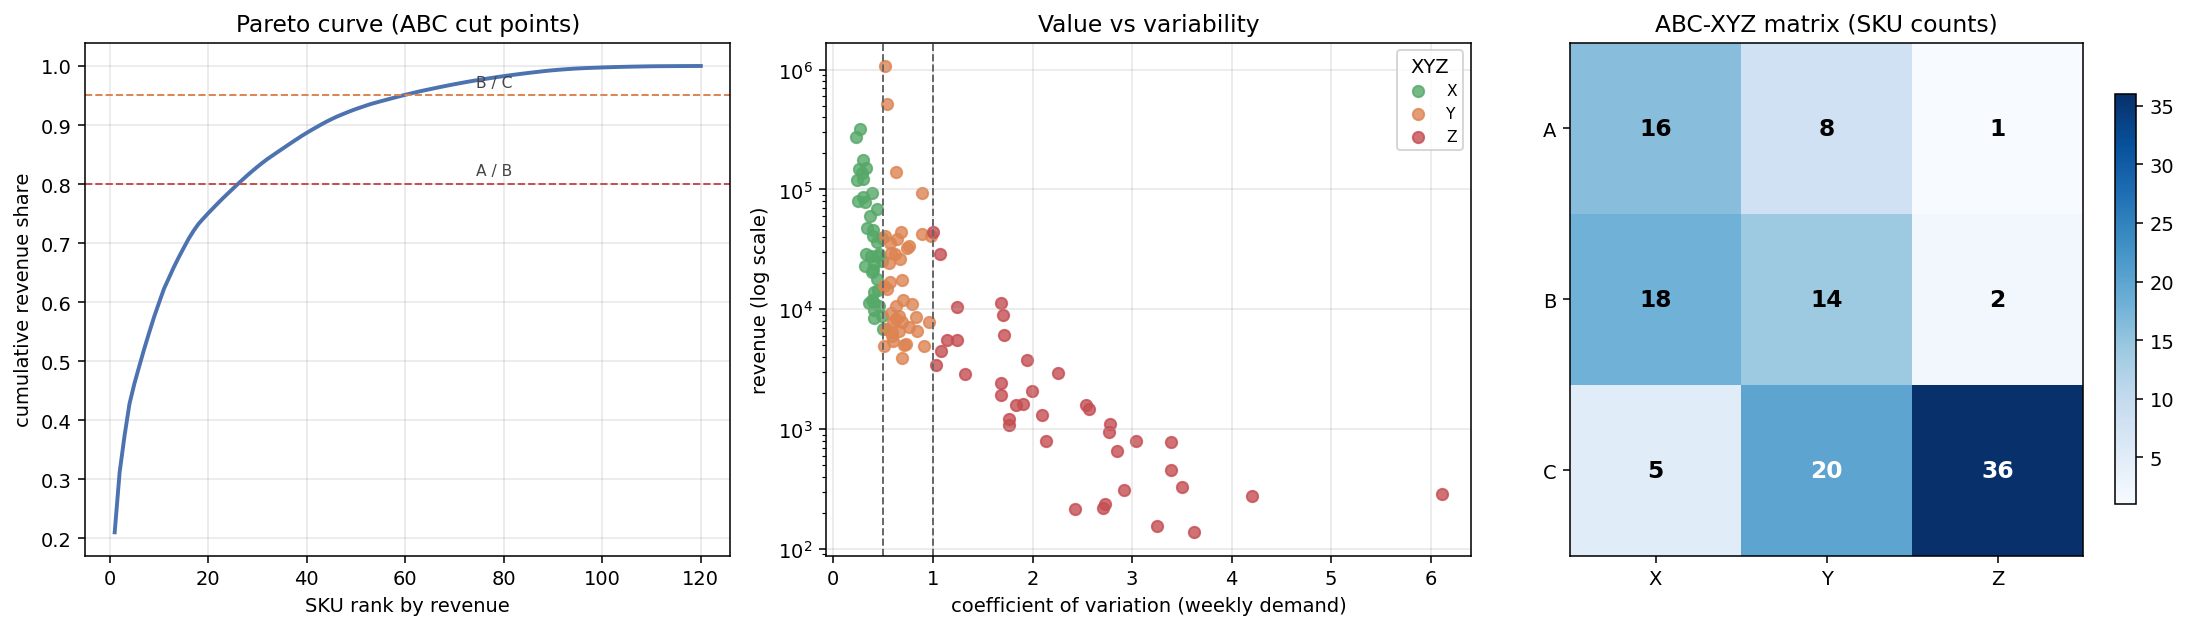

In [11]:
display(Image("../outputs/figures/02_abc_xyz.png"))

## 4. Demand forecasting

Two rules govern this section.

**Always beat a baseline.** A raw accuracy number means nothing on its own. The
ladder runs naive → seasonal naive → moving average → Holt-Winters → LightGBM,
and results are reported as improvement over *seasonal naive* (same weekday last
week). A model that cannot beat that costs complexity for nothing.

**Never random-split a time series.** Validation is rolling-origin: train on
everything up to a cutoff, predict the next 28 days, roll the cutoff forward,
repeat. A random KFold would let the model train on Friday to predict the
preceding Thursday — leakage that produces an accuracy number which collapses
in production.

**The metric is WMAPE**, not MAPE:

    WMAPE = sum|y - yhat| / sum|y|

MAPE divides by each actual individually, so zero-demand days are undefined and
near-zero days produce enormous percentages that swamp the average. Intermittent
FMCG demand is full of both.

In [12]:
focus = (seg["segments"]
         .loc[seg["segments"]["abc"].isin(["A", "B"]), "product_id"]
         .astype(str).tolist())
print(f"Forecasting {len(focus)} A/B-class SKUs "
      f"(C-class demand is too intermittent for these models)")

fc = forecasting.run(daily, sku_subset=focus)
fc["summary"]

Forecasting 59 A/B-class SKUs (C-class demand is too intermittent for these models)


,model,wmape,mae,rmse,bias,vs_seasonal_naive_pct
0,HoltWinters,0.702668,7.991311,20.344665,0.958008,24.613613
1,LightGBM,0.823442,9.380489,25.406780,5.583271,11.656201
2,SeasonalNaive,0.932089,10.610775,28.381306,0.293180,0.000000
3,Naive,0.964759,11.019774,29.412257,0.125908,-3.505092
4,MovingAvg28,1.320654,15.019061,32.705571,5.473330,-41.687567


Holt-Winters wins, beating seasonal naive by roughly a quarter. Two
observations worth stating plainly rather than tuning away:

**Holt-Winters beats LightGBM here.** At SKU-day granularity the series are
short and noisy. Holt-Winters fits per SKU, so it captures each SKU's own level
and weekly seasonality directly instead of trying to learn them from shared
features.

**LightGBM shows a large positive bias**, meaning systematic under-forecasting.
In an inventory context under-forecasting translates directly into stockouts, so
that alone would disqualify it here even if the WMAPE gap were narrower.

The moving average performing *worse* than naive is expected: a 28-day mean
smooths away the weekly seasonality that dominates this data.

In [13]:
fc["results"].pivot_table(index="fold", columns="model",
                          values="wmape").round(3)

model,HoltWinters,LightGBM,MovingAvg28,Naive,SeasonalNaive
fold,,,,,
1,0.723,0.831,1.344,0.983,0.966
2,0.713,0.837,1.355,0.943,0.930
3,0.672,0.803,1.263,0.968,0.900


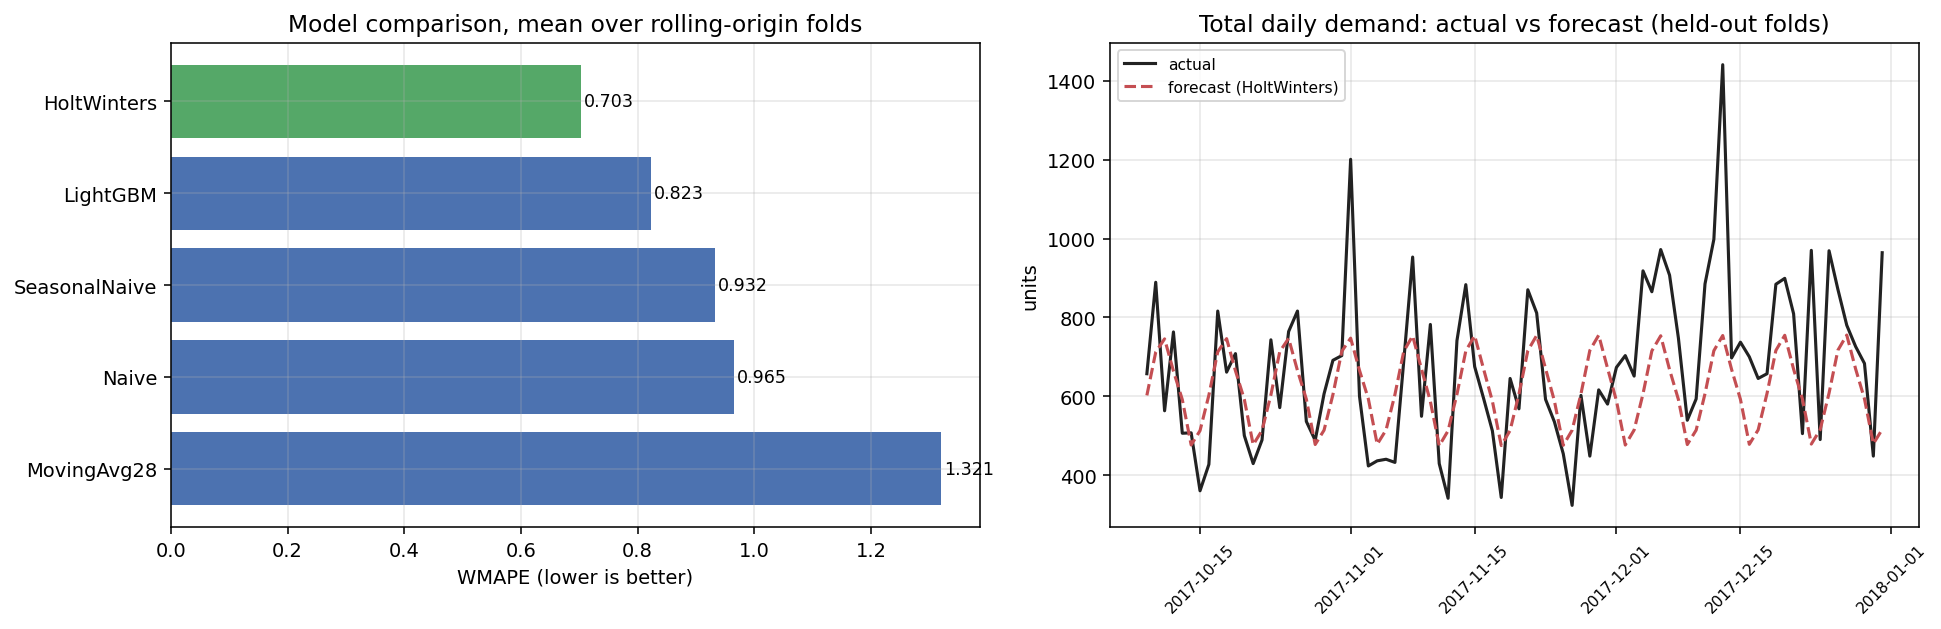

In [14]:
display(Image("../outputs/figures/03_forecast_performance.png"))

## 5. Inventory optimisation

Safety stock under **joint** demand and lead-time uncertainty:

$$SS = z\sqrt{\bar{L}\sigma_d^2 + \bar{d}^2\sigma_L^2}
\qquad ROP = \bar{d}\bar{L} + SS$$

The two terms are independent sources of risk — demand varying with lead time
fixed, and lead time varying with demand at its average — so they add as
*variances*, which is why the square root sits outside the sum. The common
shortcut $SS = z\sigma_d\sqrt{L}$ drops lead-time variability entirely and
systematically under-buffers.

Three policies are compared:

1. **Flat 21-day buffer** — the same days of cover for every SKU. This is what
   many teams actually do.
2. **Uniform 99%** — statistical safety stock, same service target everywhere.
3. **Segment-optimised** — service target varies by ABC-XYZ cell, from 98% on
   AX down to 85% on CZ.

Policy 2 exists to prove the saving comes from *differentiating* service levels,
not merely from holding less stock.

In [15]:
prices = (orders.assign(product_id=orders["product_id"].astype(str))
          .groupby("product_id", as_index=False)["unit_price"].median())
segs = seg["segments"].copy()
segs["product_id"] = segs["product_id"].astype(str)

inv = inventory.run(daily, segs, prices)
inv["comparison"]

,policy,fill_rate,avg_inventory_value,annual_holding_cost,ordering_cost,total_cost,shortfall_units,stockout_days,avg_safety_stock_units
0,Flat 21-day buffer,0.999225,137564.738757,34391.184689,14625.0,49016.184689,189.518248,18,111.013549
1,Uniform 99%,0.997004,96888.081995,24222.020499,14650.0,38872.020499,732.737219,40,47.197311
2,Segment-optimised,0.991742,89916.808391,22479.202098,14600.0,37079.202098,2019.857194,98,35.979519


### Why simulate rather than trust the formula

The formula gives **cycle service level** — the probability of not stocking out
during a replenishment cycle. The business cares about **fill rate** — the
fraction of demanded units actually served. These are different numbers, and the
gap widens for lumpy demand.

The simulation runs held-out actual demand through a continuous-review (s, Q)
policy with stochastic lead times, so fill rate is measured rather than assumed.
One implementation detail matters: the reorder decision uses **inventory
position** (on-hand plus on-order), not on-hand alone. Triggering on on-hand
would reorder every day while the first shipment is still in transit.

In [16]:
ih = inv["headline"]
print(f"Flat 21-day buffer : fill {ih['flat_fill_rate']:.2%}, "
      f"capital {ih['flat_inventory_value']:,.0f}")
print(f"Uniform 99%        : fill {ih['uniform_fill_rate']:.2%}, "
      f"capital {ih['uniform_inventory_value']:,.0f}")
print(f"Segment-optimised  : fill {ih['opt_fill_rate']:.2%}, "
      f"capital {ih['opt_inventory_value']:,.0f}")
print()
print(f"vs flat    : {ih['inventory_reduction_pct']:.1f}% less capital, "
      f"{ih['total_cost_reduction_pct']:.1f}% lower total cost")
print(f"vs uniform : {ih['vs_uniform_inventory_pct']:.1f}% less capital")

Flat 21-day buffer : fill 99.92%, capital 137,565
Uniform 99%        : fill 99.70%, capital 96,888
Segment-optimised  : fill 99.17%, capital 89,917

vs flat    : 34.6% less capital, 24.4% lower total cost
vs uniform : 7.2% less capital


The optimised policy holds a **lower** fill rate than the flat buffer.
That is a deliberate trade, not a defect, and it is the actual finding: the flat
policy buys its extra service at a large capital premium, much of it spent
buffering the C/Z tail that generates almost no revenue.

Whether the trade is worth taking depends on stockout cost versus cost of
capital — a business decision, not an analyst's. What the analysis provides is
the service-level-versus-cost curve so someone can choose their point on it
knowingly.

In [17]:
inv["curve"][["service_level", "z", "safety_stock_value",
              "annual_holding_cost", "value_vs_90pct"]]

,service_level,z,safety_stock_value,annual_holding_cost,value_vs_90pct
0,0.80,0.841621,11588.147998,2897.036999,0.656721
1,0.85,1.036433,14270.485378,3567.621344,0.808733
2,0.90,1.281552,17645.478294,4411.369573,1.000000
3,0.95,1.644854,22647.726202,5661.931551,1.283486
4,0.98,2.053749,28277.739888,7069.434972,1.602549
5,0.99,2.326348,32031.111364,8007.777841,1.815259


The curve is **convex**: each additional percentage point of service costs
more than the last. Moving from 90% to 95% is affordable; 98% to 99% is not,
and going there uniformly across a catalogue is how inventory budgets get
consumed for very little service gain.

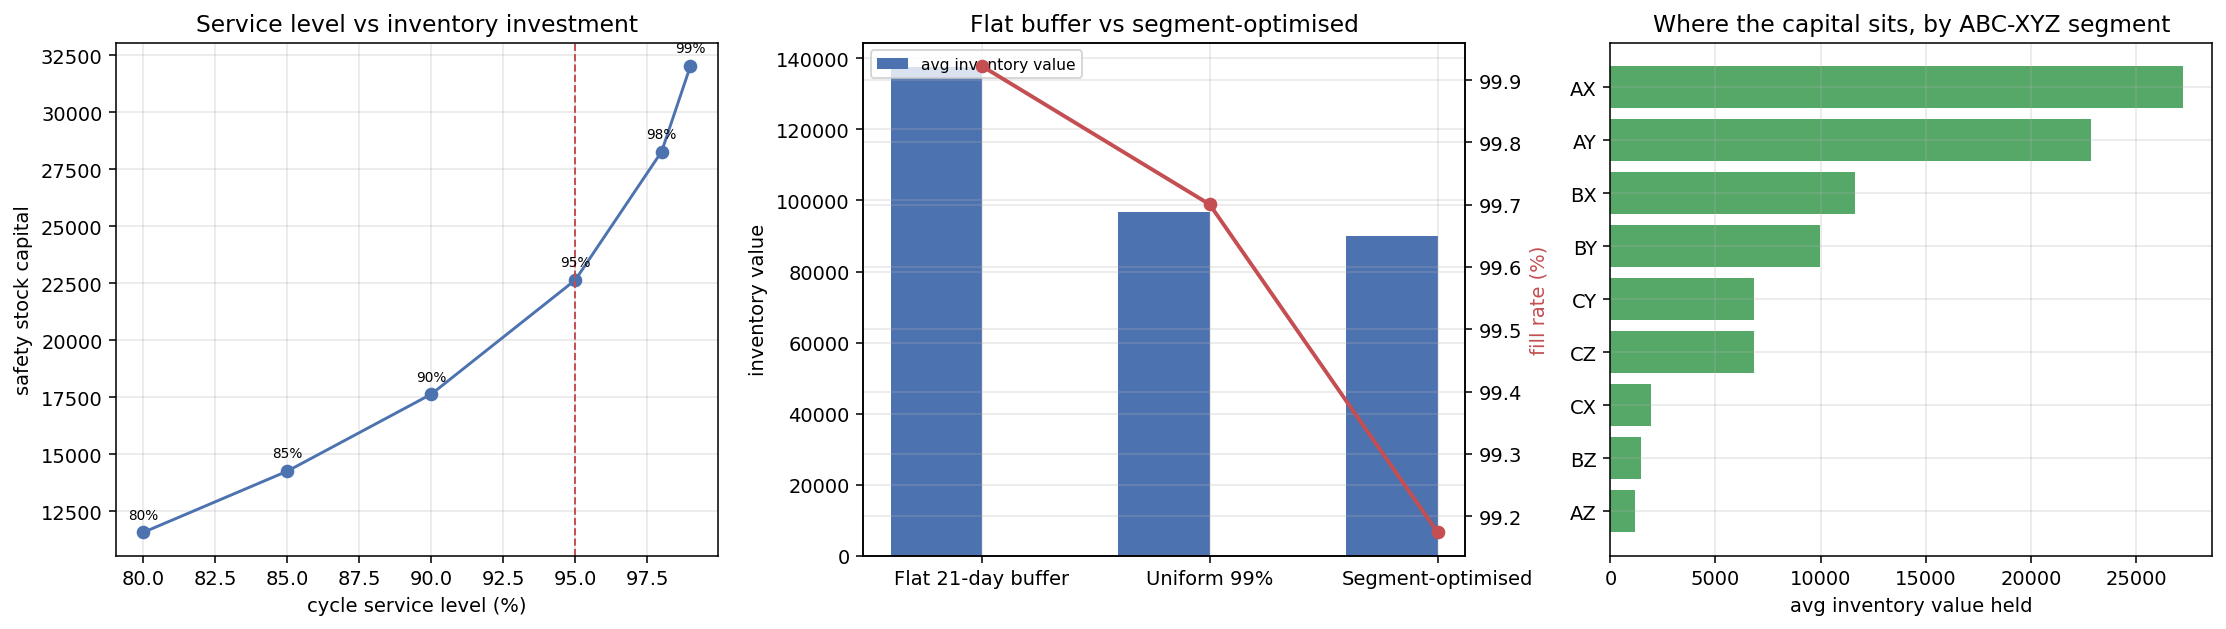

In [18]:
display(Image("../outputs/figures/04_inventory_optimisation.png"))

In [19]:
inv["policy"].nlargest(10, "annual_demand")[
    ["product_id", "segment", "d_bar", "sigma_d", "target_sl",
     "ss_opt", "rop_opt", "eoq", "order_qty"]].round(1)

,product_id,segment,d_bar,sigma_d,target_sl,ss_opt,rop_opt,eoq,order_qty
109,SKU-0110,AY,80.7,113.0,1.0,639.1,1204.3,808.6,809.0
21,SKU-0022,AX,59.7,28.0,1.0,288.7,706.5,1178.8,1179.0
108,SKU-0109,AX,40.1,24.7,1.0,212.5,492.9,1075.7,1076.0
65,SKU-0066,AY,37.3,54.5,1.0,305.2,566.2,536.3,536.0
44,SKU-0045,AX,27.9,17.6,1.0,149.2,344.5,691.9,692.0
20,SKU-0021,AX,20.2,16.8,1.0,123.4,264.7,536.7,537.0
72,SKU-0073,AX,19.3,12.4,1.0,103.8,238.6,354.8,355.0
37,SKU-0038,AX,19.0,10.6,1.0,97.0,230.1,693.8,694.0
18,SKU-0019,AY,17.4,30.6,1.0,165.6,287.4,482.7,483.0
58,SKU-0059,AX,14.7,10.7,1.0,83.6,186.4,520.0,520.0


## 6. Recommendations

**1. Fix the Standard Class lane.** It carries roughly two thirds of all late
orders. Product category is statistically unrelated to lateness, so this is a
network and carrier problem, not a product problem. Renegotiate the promised
transit time or re-route volume to Second Class in the worst regions.

**2. Re-promise rather than only re-engineer.** The average slip when late is
under two days. A large share of "failures" would disappear by setting the
scheduled date honestly, which costs nothing and improves the measured KPI
without a single operational change. Worth separating from genuine service
recovery so the two are not confused.

**3. Automate replenishment for AX SKUs.** Predictable and high value — the cell
where automation pays. Move planner attention to AZ, which carries the highest
inventory risk per rupee.

**4. Stop buffering the C/Z tail.** Move it to make-to-order or a minimum
service level. This is where the flat policy wastes most of its capital.

**5. Deploy Holt-Winters for A/B SKUs; use Croston's method for the C tail.**
Standard exponential smoothing decays toward zero between demand events, so it
is the wrong tool for intermittent series. Re-evaluate LightGBM once promotion
and price features are available.

### Limitations

- Lead times are parameterised (7 ± 2 days), not observed. The source records
  shipping duration, not supplier replenishment lead time.
- The simulation assumes lost sales, not backorders.
- Holding cost is modelled at 25% of unit cost annually — a standard planning
  assumption, not a measured figure.
- The committed figures come from the synthetic generator. Place the real
  DataCo file in `data/raw/` and re-run to regenerate against real data.